In [1]:
from data_collection import merge_csv
import pandas as pd
import numpy as np

In [2]:
train_data=merge_csv("train")
test_data=merge_csv("test")

In [3]:
train_data

,system:index,Map,NDVI,aspect,current_date,elevation,is_landslide,max_water_accumulation,prev_day_water_accumulation,prev_end,prev_start,slope,soil_temperature,today_end,today_expected_rain,today_rain_probability,today_start,volumetric_soil_moisture,water_accumulation,.geo
0,0,10,0.218753,207.104187,2020-04-12,375.650208,1,1.0,0.000000,2020-04-12,2020-04-11,20.355526,302.205963,2020-04-13,0.000000,0.000000,2020-04-12,0.380516,1.0,"{""type"":""Point"",""coordinates"":[75.868056,11.49..."
1,1,10,0.284937,269.185455,2022-10-30,274.729340,1,4.0,17.119999,2022-10-30,2022-10-29,32.054546,299.180603,2022-10-31,11.160000,14.583333,2022-10-30,0.403540,4.0,"{""type"":""Point"",""coordinates"":[75.8665,11.4926]}"
2,2,10,0.255333,103.869324,2020-06-03,613.916504,1,1.0,81.250000,2020-06-03,2020-06-02,21.678421,299.431763,2020-06-04,32.959999,37.500000,2020-06-03,0.483854,1.0,"{""type"":""Point"",""coordinates"":[75.842222,11.50..."
3,3,10,0.680487,99.773178,2019-01-29,124.405884,1,2.0,0.000000,2019-01-29,2019-01-28,25.236725,300.545959,2019-01-30,0.000000,0.000000,2019-01-29,0.255892,1.0,"{""type"":""Point"",""coordinates"":[75.843889,11.51..."
4,4,10,0.251248,60.641186,2022-12-10,105.926308,1,7.0,131.039993,2022-12-10,2022-12-09,17.843731,296.983307,2022-12-11,6.090000,6.250000,2022-12-10,0.405192,7.0,"{""type"":""Point"",""coordinates"":[75.846667,11.51..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,995,10,-0.010146,269.312683,2019-08-22,2010.202393,0,5.0,3.300000,2019-08-22,2019-08-21,11.127341,294.871704,2019-08-23,43.439999,18.750000,2019-08-22,0.466738,1.0,"{""type"":""Point"",""coordinates"":[94.802672213387..."
9996,996,10,0.610598,126.181892,2020-03-30,294.689301,0,2102.0,0.000000,2020-03-30,2020-03-29,17.714508,298.121307,2020-03-31,0.000000,0.000000,2020-03-30,0.337807,1.0,"{""type"":""Point"",""coordinates"":[93.273087487507..."
9997,997,40,0.388469,267.036072,2022-11-04,24.569622,0,2.0,0.000000,2022-11-04,2022-11-03,2.336384,297.198334,2022-11-05,0.000000,0.000000,2022-11-04,0.303999,1.0,"{""type"":""Point"",""coordinates"":[89.390411738690..."
9998,998,10,0.089068,52.482162,2019-05-28,17.538542,0,3.0,11.339999,2019-05-28,2019-05-27,3.444953,299.763428,2019-05-29,0.420000,0.000000,2019-05-28,0.448299,3.0,"{""type"":""Point"",""coordinates"":[91.561613335781..."


In [4]:
train_data.shape

(10000, 20)

In [5]:
train_data.value_counts()

system:index  Map  NDVI       aspect      current_date  elevation    is_landslide  max_water_accumulation  prev_day_water_accumulation  prev_end    prev_start  slope      soil_temperature  today_end   today_expected_rain  today_rain_probability  today_start  volumetric_soil_moisture  water_accumulation  .geo                                                                 
998           10    0.155042  177.413391  2023-07-09    677.392151   1             8.0                     62.320000                    2023-07-09  2023-07-08  29.076071  293.651489        2023-07-10  0.000000             0.000000                2023-07-09   0.499898                  8.0                 {"type":"Point","coordinates":[77.079923,9.887064]}                      1
                    0.103591  154.415176  2020-06-15    1372.058228  1             45.0                    0.000000                     2020-06-15  2020-06-14  17.635080  296.042389        2020-06-16  6.690000             8.333333               

In [6]:
train_data['expected_accumulation']=train_data['prev_day_water_accumulation']+train_data['today_expected_rain']*train_data['today_expected_rain']
slope_rad = np.radians(train_data['slope'])
train_data['TWI'] = np.log((train_data['water_accumulation'] + 0.001) / (np.tan(slope_rad) + 0.001))
train_df=train_data.drop(columns=['system:index','prev_end','prev_start','today_end','today_start','.geo','current_date','prev_day_water_accumulation'],axis=1)




test_data['expected_accumulation']=test_data['prev_day_water_accumulation']+test_data['today_expected_rain']*test_data['today_expected_rain']
slope_rad = np.radians(train_data['slope'])
test_data['TWI'] = np.log((test_data['water_accumulation'] + 0.001) / (np.tan(slope_rad) + 0.001))
test_df=test_data.drop(columns=['system:index','prev_end','prev_start','today_end','today_start','.geo','current_date','prev_day_water_accumulation'],axis=1)


In [7]:
test_df

,Map,NDVI,aspect,elevation,is_landslide,max_water_accumulation,slope,soil_temperature,today_expected_rain,today_rain_probability,volumetric_soil_moisture,water_accumulation,expected_accumulation,TWI
0,10,0.059342,207.104187,375.650208,1,1.0,20.355526,298.651367,28.639999,16.666666,0.483559,1.0,839.159565,0.989825
1,10,0.646148,269.185455,274.729340,1,4.0,32.054546,303.330170,0.000000,0.000000,0.238437,4.0,0.000000,1.853044
2,10,0.076781,103.869324,613.916504,1,1.0,21.678421,298.016296,0.000000,0.000000,0.506729,1.0,3.570000,0.921017
3,10,0.815811,99.773178,124.405884,1,2.0,25.236725,300.355469,0.340000,0.000000,0.275890,1.0,0.115600,0.751040
4,10,0.040471,60.641186,105.926308,1,7.0,17.843731,299.745697,15.429999,16.666666,0.497597,7.0,240.604880,3.076444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10,0.326182,179.107437,2.269323,0,1.0,1.611909,294.377472,0.000000,0.000000,0.104842,1.0,0.000000,1.622066
9996,10,0.693166,290.612000,1085.006226,0,7.0,26.803743,291.538483,0.000000,0.000000,0.186104,7.0,0.000000,3.084176
9997,10,0.665585,258.405884,614.216858,0,2.0,16.126448,292.140137,0.000000,0.000000,0.280991,2.0,0.000000,3.868501
9998,10,0.053031,198.178711,13.648597,0,1.0,6.314781,301.953247,33.959999,25.000000,0.390332,1.0,1153.281538,2.794635


In [8]:
test_df.shape

(10000, 14)

In [9]:
train_df.columns

Index(['Map', 'NDVI', 'aspect', 'elevation', 'is_landslide',
       'max_water_accumulation', 'slope', 'soil_temperature',
       'today_expected_rain', 'today_rain_probability',
       'volumetric_soil_moisture', 'water_accumulation',
       'expected_accumulation', 'TWI'],
      dtype='object')

In [10]:
train_df

,Map,NDVI,aspect,elevation,is_landslide,max_water_accumulation,slope,soil_temperature,today_expected_rain,today_rain_probability,volumetric_soil_moisture,water_accumulation,expected_accumulation,TWI
0,10,0.218753,207.104187,375.650208,1,1.0,20.355526,302.205963,0.000000,0.000000,0.380516,1.0,0.000000,0.989825
1,10,0.284937,269.185455,274.729340,1,4.0,32.054546,299.180603,11.160000,14.583333,0.403540,4.0,141.665596,1.853044
2,10,0.255333,103.869324,613.916504,1,1.0,21.678421,299.431763,32.959999,37.500000,0.483854,1.0,1167.611540,0.921017
3,10,0.680487,99.773178,124.405884,1,2.0,25.236725,300.545959,0.000000,0.000000,0.255892,1.0,0.000000,0.751040
4,10,0.251248,60.641186,105.926308,1,7.0,17.843731,296.983307,6.090000,6.250000,0.405192,7.0,168.128089,3.076444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10,-0.010146,269.312683,2010.202393,0,5.0,11.127341,294.871704,43.439999,18.750000,0.466738,1.0,1890.333481,1.622066
9996,10,0.610598,126.181892,294.689301,0,2102.0,17.714508,298.121307,0.000000,0.000000,0.337807,1.0,0.000000,1.139123
9997,40,0.388469,267.036072,24.569622,0,2.0,2.336384,297.198334,0.000000,0.000000,0.303999,1.0,0.000000,3.175854
9998,10,0.089068,52.482162,17.538542,0,3.0,3.444953,299.763428,0.420000,0.000000,0.448299,3.0,11.516399,3.892581


In [11]:
y_train=train_df['is_landslide']
X_train=train_df.drop(columns=['is_landslide'],axis=1)
y_test=test_df['is_landslide']
X_test=test_df.drop(columns=['is_landslide'],axis=1)


In [12]:
from scaler import standardise_data
(X_train_scaled,X_test_scaled)=standardise_data(X_train,X_test)

In [13]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier()
xgb_model.fit(X_train, y_train)

# Get the probability of a landslide (Class 1) for the test set
# [:, 1] grabs the probability for the positive class
y_probs = xgb_model.predict_proba(X_test)[:, 1]


from sklearn.metrics import classification_report, confusion_matrix

# 1. Convert probabilities to 1 (Landslide) only if > 80%
# (astype(int) cleanly turns True/False into 1/0)
y_pred_high_risk = (y_probs > 0.71).astype(int)

# 2. Print the evaluation metrics
print("--- EVALUATION AT >80% PROBABILITY THRESHOLD ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_high_risk))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_high_risk))


--- EVALUATION AT >80% PROBABILITY THRESHOLD ---

Confusion Matrix:
[[4556  444]
 [ 494 4506]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      5000
           1       0.91      0.90      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [14]:
import numpy
from sklearn.metrics import recall_score

# Loop through thresholds from 0.50 down to 0.01
for thresh in np.arange(0.90, 0.0, -0.01):
    # Apply the current threshold
    y_pred_temp = (y_probs > thresh).astype(int)
    
    # Calculate recall (True Positive Rate)
    current_recall = recall_score(y_test, y_pred_temp)
    
    # If recall hits 90% (meaning False Negatives are <10%)
    if current_recall >= 0.90:
        print(f"✅ Optimal Threshold Found: {thresh:.2f}")
        print("\nNew Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred_temp))
        print("\nNew Classification Report:")
        print(classification_report(y_test, y_pred_temp))
        break

✅ Optimal Threshold Found: 0.71

New Confusion Matrix:
[[4556  444]
 [ 494 4506]]

New Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      5000
           1       0.91      0.90      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



Success! Model saved safely as sih_landslide_xgb_model.pkl


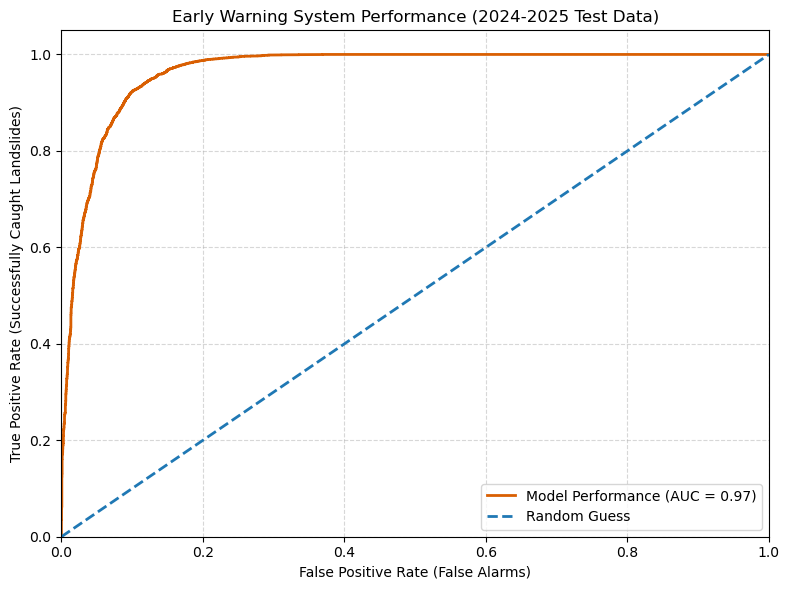

In [15]:
# import pickle as pkl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# --- 1. SAVE THE FINAL MODEL ---
# This saves the model weights so you don't have to retrain tomorrow
model_filename = 'sih_landslide_xgb_model.pkl'
print(f"Success! Model saved safely as {model_filename}")

# --- 2. GENERATE THE ROC CURVE FOR PRESENTATION ---
# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plotting the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#d95f02', lw=2, label=f'Model Performance (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='#1f78b4', lw=2, linestyle='--', label='Random Guess')

# Formatting for the judges
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Successfully Caught Landslides)')
plt.title('Early Warning System Performance (2024-2025 Test Data)')
plt.legend(loc="lower right")
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the plot
plt.show()

In [16]:
# import xgboost as xgb

# # Define a regularized XGBoost model
# xgb_model = xgb.XGBClassifier(
#     n_estimators=200,        # Number of trees
#     max_depth=4,             # Force shallow trees (default is 6)
#     learning_rate=0.05,      # Slower learning prevents jumping to false conclusions
#     subsample=0.8,           # Use 80% of rows per tree (adds randomness)
#     colsample_bytree=0.8,    # Use 80% of columns per tree (prevents relying on one feature)
#     min_child_weight=3,      # Require more evidence to create a new branch
#     random_state=42
# )

# # Fit the model
# xgb_model.fit(X_train_scaled, Y_train)
# # Predict
# Y_train_pred=xgb_model.predict(X_train_scaled)
# Y_test_pred=xgb_model.predict(X_test)

In [17]:
# from sklearn.metrics import classification_report,confusion_matrix
# print(f"The Confusion Matrix of Training Data: \n{confusion_matrix(Y_train,Y_train_pred)}  \n\n")
# print(f"The Confusion Matrix of Test Data: \n{confusion_matrix(Y_test,Y_test_pred)} \n\n")
# print(f"The Classification Report of Training Data:\n {classification_report(Y_train,Y_train_pred)}  \n\n")
# print(f"The Classification Report of Test Data:\n {classification_report(Y_test,Y_test_pred)} \n\n")

In [18]:
# print("--- TRAIN MEANS (2019-2023) ---")
# print(X_train[['rainfall_total', 'volumetric_soil_moisture', 'NDVI']].mean())

# print("\n--- TEST MEANS (2024-2025) ---")
# print(X_test[['rainfall_total', 'volumetric_soil_moisture', 'NDVI']].mean())

In [19]:
# # 1. Verify exact column matching and ordering
# print("Columns match exactly?", list(X_train.columns) == list(X_test.columns))
# print("Train columns:", list(X_train.columns))
# print("Test columns: ", list(X_test.columns))

# # 2. Check feature importances to see which variable dominated
# import pandas as pd

# importance_check = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': xgb_model.feature_importances_
# }).sort_values(by='Importance', ascending=False)

# print("\n--- FEATURE IMPORTANCES ---")
# print(importance_check)

In [20]:
# static_features = ['elevation', 'aspect', 'LULC','slope','volumetric_soil_moisture','NDVI']

# X_train_static = X_train[static_features]
# X_test_static = X_test[static_features]
# # Create the interaction features for the Training Set
# X_train_static['rain_slope_index'] = X_train['rainfall_total'] * X_train['slope']
# X_train_static['moisture_slope_index'] = X_train['volumetric_soil_moisture'] * X_train['slope']
# # You MUST do the exact same for the Test Set so the columns match
# X_test_static['rain_slope_index'] = X_test['rainfall_total'] * X_test['slope']
# X_test_static['moisture_slope_index'] = X_test['volumetric_soil_moisture'] * X_test['slope']
# from sklearn.preprocessing import StandardScaler
# scaler=StandardScaler()
# X_train_static=scaler.fit_transform(X_train_static)
# X_test_static=scaler.transform(X_test_static)
# print("New Features Engineered Successfully!")

# # 2. Retrain the model on the stable data
# xgb_model.fit(X_train_static, Y_train)

# # 3. Predict on the 2024-2025 test set
# Y_pred_static = xgb_model.predict(X_test_static)

# # 4. Evaluate the new, weather-proof model
# from sklearn.metrics import classification_report, confusion_matrix
# print("--- STATIC TERRAIN MODEL RESULTS ---")
# print(confusion_matrix(Y_test, Y_pred_static))
# print(classification_report(Y_test, Y_pred_static))

# Retrain the model with the new engineered features
# from xgboost import XGBClassifier
# xgb_model=XGBClassifier(
  
#  )
# xgb_model.fit(X_train_static, Y_train)

# # Get the probability of a landslide (Class 1) for the test set
# # [:, 1] grabs the probability for the positive class
# y_probs = xgb_model.predict_proba(X_test_static)[:, 1]

# # View the first 5 probabilities
# print("Raw Probabilities for first 5 points:", y_probs[:5])


# from sklearn.metrics import classification_report, confusion_matrix

# # 1. Convert probabilities to 1 (Landslide) only if > 80%
# # (astype(int) cleanly turns True/False into 1/0)
# y_pred_high_risk = (y_probs > 0.41).astype(int)

# # 2. Print the evaluation metrics
# print("--- EVALUATION AT >80% PROBABILITY THRESHOLD ---")
# print("\nConfusion Matrix:")
# print(confusion_matrix(Y_test, y_pred_high_risk))

# print("\nClassification Report:")
# print(classification_report(Y_test, y_pred_high_risk))

# import numpy as np
# import pandas as pd

# # Create a DataFrame to view the results
# results_df = pd.DataFrame({
#     'Actual_Label': y_test,
#     'Landslide_Probability': y_probs
# })

# # Define the SIH Early Warning thresholds
# conditions = [
#     (results_df['Landslide_Probability'] > 0.80),
#     (results_df['Landslide_Probability'] > 0.50),
#     (results_df['Landslide_Probability'] <= 0.50)
# ]
# choices = ['High Risk (Evacuate)', 'Moderate Risk (Monitor)', 'Low Risk']

# # Apply the conditions
# results_df['Risk_Level'] = np.select(conditions, choices, default='Unknown')

# # Check how many points fell into each category
# print(results_df['Risk_Level'].value_counts())

In [21]:
# import numpy
# from sklearn.metrics import recall_score

# # Loop through thresholds from 0.50 down to 0.01
# for thresh in np.arange(0.90, 0.0, -0.01):
#     # Apply the current threshold
#     y_pred_temp = (y_probs > thresh).astype(int)
    
#     # Calculate recall (True Positive Rate)
#     current_recall = recall_score(Y_test, y_pred_temp)
    
#     # If recall hits 90% (meaning False Negatives are <10%)
#     if current_recall >= 0.90:
#         print(f"✅ Optimal Threshold Found: {thresh:.2f}")
#         print("\nNew Confusion Matrix:")
#         print(confusion_matrix(Y_test, y_pred_temp))
#         print("\nNew Classification Report:")
#         print(classification_report(Y_test, y_pred_temp))
#         break